In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys 
sys.path.append('../src')

from cnn import * 
from datas import SequenceBigWigClusterDataset
from train import *

In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [23]:
# timepoint = '2H'
# bigwig_path = '../data/bws_for_predictor/SPT16_4D_2HdTAG_Sox2_S46_1_120_sorted.bw'

timepoint = 'DMSO'
bigwig_path = '../data/bws_for_predictor/SPT16_4D_DMSO_Sox2_S40_1_120_sorted.bw'

fasta_path = '../data/GRCm38.primary_assembly.genome.fa'
bed_path = '../data/bed_files/SOX2_clusters_sorted.bed'

signal_bins = None
batch_size = 256
epochs = 1000
lr = 1e-2
weight_decay=1e-4
device = 'mps'
patience = 10
sidelines = 0
target_smoothing = False
rc_augment = True
subset_cluster = ['cluster_1', 'cluster_2']


In [5]:
window_left = 1000
window_right = 1000
model_dir = 'models_class'

In [6]:
# real training
config = TrainConfig(
    lr=lr,
    weight_decay=weight_decay,
    epochs=epochs,
    device=device,
    patience=patience,
    loss_type='bpnet',
    min_profile=3000,
    sidelines=sidelines,
    target_smoothing=target_smoothing,
    rc_augment=rc_augment
)

In [7]:
dataset = SequenceBigWigClusterDataset(
    fasta_path=str(fasta_path),
    bigwig_path=str(bigwig_path),
    bed_path=str(bed_path),
    signal_bins=signal_bins,
    window_left=window_left,
    window_right=window_right,
    subset_dict={'deepTools_group': subset_cluster}
)

### Sanity check

In [8]:
len(dataset)

1020

In [9]:
from torch.utils.data import DataLoader
import numpy as np

loader = DataLoader(dataset, batch_size=256, num_workers=1, shuffle=False)

arr = []
tot_counts = []

for *_, label, y_batch in loader:
    arr.append(label.numpy())
    tot_counts.append(y_batch.numpy())

tot_counts = np.vstack(tot_counts)
arr = np.concatenate(arr)

In [10]:
# since this is binary classification this is fine
# if adding more clusters it needs to be one hot later on
np.unique(arr, return_counts=True)

(array([0, 1]), array([519, 501]))

'DMSO'

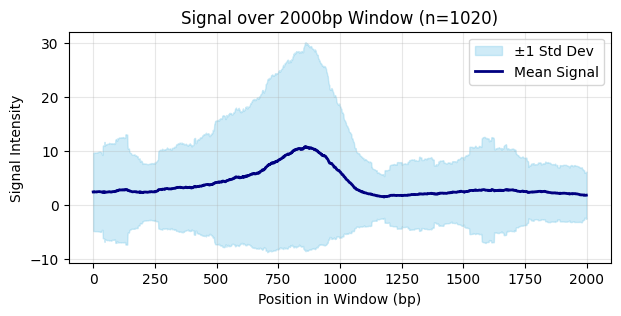

In [11]:
mean_line = np.mean(tot_counts, axis=0)
std_line = np.std(tot_counts, axis=0)
x = np.arange(len(mean_line))

plt.figure(figsize=(7, 3))

plt.fill_between(x, mean_line - std_line, mean_line + std_line, 
                 color='skyblue', alpha=0.4, label='±1 Std Dev')

plt.plot(x, mean_line, color='navy', lw=2, label='Mean Signal')

plt.title(f"Signal over {len(mean_line)}bp Window (n={tot_counts.shape[0]})")
plt.xlabel("Position in Window (bp)")
plt.ylabel("Signal Intensity")
plt.legend()
plt.grid(True, alpha=0.3)

timepoint

In [12]:
tot_counts[arr == 0].sum(axis=1).mean()

np.float32(9095.651)

In [13]:
tot_counts[arr == 1].sum(axis=1).mean()

np.float32(5772.0186)

### Train

In [38]:
# real training
config = TrainConfig(
    lr=lr,
    weight_decay=weight_decay,
    epochs=epochs,
    device=device,
    patience=patience,
    loss_type='bpnet',
    min_profile=2000,
    sidelines=sidelines,
    target_smoothing=target_smoothing,
    rc_augment=rc_augment
)

model = train_cnn_regressor(
    dataset=dataset,
    batch_size=batch_size,
    config=config,
)

Receptive field: 535 bp (Sequence length: 2000 bp)


Epoch 1/1000 - train: 666.4313 | val: 1.1049 
Epoch 2/1000 - train: 0.9070 | val: 0.8674 
Epoch 3/1000 - train: 0.8111 | val: 0.9188 
Epoch 4/1000 - train: 0.8439 | val: 0.8941 
Epoch 5/1000 - train: 0.8135 | val: 0.8225 
Epoch 6/1000 - train: 0.7638 | val: 0.7624 
Epoch 7/1000 - train: 0.7206 | val: 0.7355 
Epoch 8/1000 - train: 0.7116 | val: 0.7249 
Epoch 9/1000 - train: 0.7117 | val: 0.7186 
Epoch 10/1000 - train: 0.7038 | val: 0.7137 
Epoch 11/1000 - train: 0.7064 | val: 0.7100 
Epoch 12/1000 - train: 0.7002 | val: 0.7068 
Epoch 13/1000 - train: 0.6991 | val: 0.7042 
Epoch 14/1000 - train: 0.6943 | val: 0.7020 
Epoch 15/1000 - train: 0.6970 | val: 0.7006 
Epoch 16/1000 - train: 0.6965 | val: 0.6992 
Epoch 17/1000 - train: 0.6954 | val: 0.6981 
Epoch 18/1000 - train: 0.6955 | val: 0.6972 
Epoch 19/1000 - train: 0.6967 | val: 0.6967 
Epoch 20/1000 - train: 0.6950 | val: 0.6962 
Epoch 21/1000 - train: 0.6945 | val: 0.6960 
Epoch 22/1000 - train: 0.6952 | val: 0.6956 
Epoch 23/1000 - t

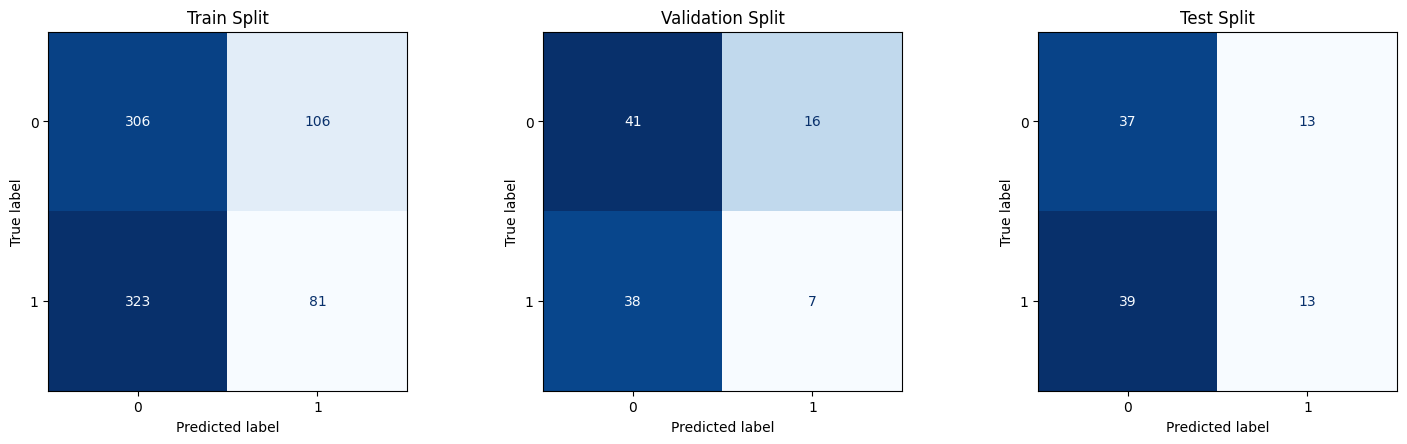

In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

train_res = evaluate_model_metrics(model, model.train_loader, device=config.device)
val_res = evaluate_model_metrics(model, model.val_loader, device=config.device)
test_res = evaluate_model_metrics(model, model.test_loader, device=config.device)

splits = {
    "Train": train_res,
    "Validation": val_res,
    "Test": test_res
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (split_name, res) in zip(axes, splits.items()):
    true_labels = np.array(res["class_true"])
    pred_labels = (np.array(res["class_pred"]) >= 0.5).astype(int)
    
    cm = confusion_matrix(true_labels, pred_labels)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{split_name} Split")

plt.tight_layout()
plt.show()


In [ ]:
import time
from pathlib import Path

date = time.strftime("%m%d")
model_name = f'seq_{timepoint}_classifier_{date}'
output_model_path = Path(f'../{model_dir}/{model_name}.pt')
model_name

In [ ]:
import os 

results_dir = f'../results/{model_name}'
os.makedirs(results_dir, exist_ok=True)

In [ ]:
from evaluate import evaluate_baselines, plot_counts_correlation, evaluate_baselines_sig

df_corr, loader_metrics = evaluate_baselines(model, results_dir=results_dir)
# df_stats = evaluate_baselines_sig(loader_metrics, results_dir=results_dir)

plot_counts_correlation(loader_metrics, model_name=model_name, results_dir=results_dir)